In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

/opt/anaconda3/lib/python3.11/site-packages/pandas/core/computation/expressions.py:22: UserWarning: Pandas requires version '2.10.2' or newer of 'numexpr' (version '2.8.7' currently installed).
  from pandas.core.computation.check import NUMEXPR_INSTALLED
/opt/anaconda3/lib/python3.11/site-packages/pandas/core/arrays/masked.py:56: UserWarning: Pandas requires version '1.4.2' or newer of 'bottleneck' (version '1.3.7' currently installed).
  from pandas.core import (


CheckPoint 1

In [2]:
df=pd.read_csv('Telco-Customer-Churn.csv')

In [3]:
df.head()

,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,...,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,7590-VHVEG,Female,0,Yes,No,1,No,No phone service,DSL,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No
1,5575-GNVDE,Male,0,No,No,34,Yes,No,DSL,Yes,...,Yes,No,No,No,One year,No,Mailed check,56.95,1889.5,No
2,3668-QPYBK,Male,0,No,No,2,Yes,No,DSL,Yes,...,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes
3,7795-CFOCW,Male,0,No,No,45,No,No phone service,DSL,Yes,...,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,No
4,9237-HQITU,Female,0,No,No,2,Yes,No,Fiber optic,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,Yes


In [4]:
df.shape

(7043, 21)

In [5]:
df.dtypes

customerID              str
gender                  str
SeniorCitizen         int64
Partner                 str
Dependents              str
tenure                int64
PhoneService            str
MultipleLines           str
InternetService         str
OnlineSecurity          str
OnlineBackup            str
DeviceProtection        str
TechSupport             str
StreamingTV             str
StreamingMovies         str
Contract                str
PaperlessBilling        str
PaymentMethod           str
MonthlyCharges      float64
TotalCharges            str
Churn                   str
dtype: object

In [6]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 7043 entries, 0 to 7042
Data columns (total 21 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   customerID        7043 non-null   str    
 1   gender            7043 non-null   str    
 2   SeniorCitizen     7043 non-null   int64  
 3   Partner           7043 non-null   str    
 4   Dependents        7043 non-null   str    
 5   tenure            7043 non-null   int64  
 6   PhoneService      7043 non-null   str    
 7   MultipleLines     7043 non-null   str    
 8   InternetService   7043 non-null   str    
 9   OnlineSecurity    7043 non-null   str    
 10  OnlineBackup      7043 non-null   str    
 11  DeviceProtection  7043 non-null   str    
 12  TechSupport       7043 non-null   str    
 13  StreamingTV       7043 non-null   str    
 14  StreamingMovies   7043 non-null   str    
 15  Contract          7043 non-null   str    
 16  PaperlessBilling  7043 non-null   str    
 17  Paymen

In [7]:
df.describe()

,SeniorCitizen,tenure,MonthlyCharges
count,7043.000000,7043.000000,7043.000000
mean,0.162147,32.371149,64.761692
std,0.368612,24.559481,30.090047
min,0.000000,0.000000,18.250000
25%,0.000000,9.000000,35.500000
50%,0.000000,29.000000,70.350000
75%,0.000000,55.000000,89.850000
max,1.000000,72.000000,118.750000


In [8]:
df.isnull().sum()

customerID          0
gender              0
SeniorCitizen       0
Partner             0
Dependents          0
tenure              0
PhoneService        0
MultipleLines       0
InternetService     0
OnlineSecurity      0
OnlineBackup        0
DeviceProtection    0
TechSupport         0
StreamingTV         0
StreamingMovies     0
Contract            0
PaperlessBilling    0
PaymentMethod       0
MonthlyCharges      0
TotalCharges        0
Churn               0
dtype: int64

In [9]:
df.duplicated().sum()

0

CheckPoint 2

In [10]:
df.isnull().sum()

customerID          0
gender              0
SeniorCitizen       0
Partner             0
Dependents          0
tenure              0
PhoneService        0
MultipleLines       0
InternetService     0
OnlineSecurity      0
OnlineBackup        0
DeviceProtection    0
TechSupport         0
StreamingTV         0
StreamingMovies     0
Contract            0
PaperlessBilling    0
PaymentMethod       0
MonthlyCharges      0
TotalCharges        0
Churn               0
dtype: int64

In [11]:
(df == " ").sum()

customerID           0
gender               0
SeniorCitizen        0
Partner              0
Dependents           0
tenure               0
PhoneService         0
MultipleLines        0
InternetService      0
OnlineSecurity       0
OnlineBackup         0
DeviceProtection     0
TechSupport          0
StreamingTV          0
StreamingMovies      0
Contract             0
PaperlessBilling     0
PaymentMethod        0
MonthlyCharges       0
TotalCharges        11
Churn                0
dtype: int64

In [12]:
df["TotalCharges"] = df["TotalCharges"].replace(" ", np.nan)
df["TotalCharges"] = pd.to_numeric(df["TotalCharges"], errors="coerce")
df = df.dropna(subset=["TotalCharges"])
df.isnull().sum()


# Hər bir sütun üzrə çatışmayan dəyərləri yoxladım və TotalCharges sütununda həqiqi null dəyərlər əvəzinə boşluqların (" ") olduğunu müəyyən etdim.
# Bu boşluqları NaN dəyərlərinə çevirdim. Onların sayı məlumat dəstində çox az idi deyə, məlumatın keyfiyyətini qorumaq məqsədilə həmin sətirlər sildim. 


customerID          0
gender              0
SeniorCitizen       0
Partner             0
Dependents          0
tenure              0
PhoneService        0
MultipleLines       0
InternetService     0
OnlineSecurity      0
OnlineBackup        0
DeviceProtection    0
TechSupport         0
StreamingTV         0
StreamingMovies     0
Contract            0
PaperlessBilling    0
PaymentMethod       0
MonthlyCharges      0
TotalCharges        0
Churn               0
dtype: int64

CheckPoint 3

In [13]:
numeric_cols = [
    col for col in df.select_dtypes(include=np.number).columns
    if df[col].nunique() > 2
]

In [14]:
for col in numeric_cols:
    Q1 = df[col].quantile(0.25)
    Q3 = df[col].quantile(0.75)
    IQR = Q3 - Q1

    lower = Q1 - 1.5 * IQR
    upper = Q3 + 1.5 * IQR

    outliers = df[(df[col] < lower) | (df[col] > upper)]

    print(f"{col}: {len(outliers)} outliers")

#IQR metodundan istifadə edərək ədədi sütunlarda outlier-ləri yoxladım. Aparılan analiz nəticəsində tenure,
# MonthlyCharges və TotalCharges və digər numeric sütunlarda outlier tapmadım. Buna görə bu mərhələdə datasetdə heç bir dəyişiklik etmədim.

tenure: 0 outliers
MonthlyCharges: 0 outliers
TotalCharges: 0 outliers


CheckPoint 4

In [15]:
df["CLV"] = df["tenure"] * df["MonthlyCharges"]

In [16]:
def tenure_group(x):
    if x <= 12:
        return "New Customer"
    elif x <= 36:
        return "Regular Customer"
    else:
        return "Loyal Customer"

In [17]:
df["Tenure_Group"] = df["tenure"].apply(tenure_group)

In [18]:
def charge_category(x):
    if x < 35:
        return "Low"
    elif x < 70:
        return "Medium"
    else:
        return "High"

df["MonthlyCharge_Category"] = df["MonthlyCharges"].apply(
    charge_category
)


In [19]:
df["Contract_Risk"] = df["Contract"].map({
    "Month-to-month": "High Risk",
    "One year": "Medium Risk",
    "Two year": "Low Risk"
})


In [20]:
df[[
    "CLV",
    "Tenure_Group",
    "MonthlyCharge_Category",
    "Contract_Risk"
]].head()

,CLV,Tenure_Group,MonthlyCharge_Category,Contract_Risk
0,29.85,New Customer,Low,High Risk
1,1936.30,Regular Customer,Medium,Medium Risk
2,107.70,New Customer,Medium,High Risk
3,1903.50,Loyal Customer,Medium,Medium Risk
4,141.40,New Customer,High,High Risk


CheckPoint 5

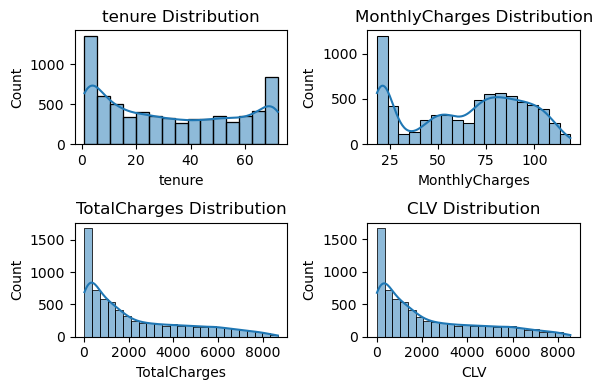

In [21]:
numeric_cols = ["tenure", "MonthlyCharges", "TotalCharges", "CLV"]
plt.figure(figsize=(6,4))
for i, col in enumerate(numeric_cols, 1):
    plt.subplot(2,2,i)
    sns.histplot(
        data=df,
        x=col,
        kde=True
    )
    plt.title(f"{col} Distribution")

plt.tight_layout()
plt.show()

#Bu qrafiklər numeric sütunların məlumatda necə paylandığını göstərir.

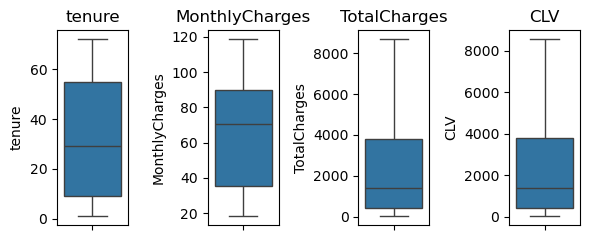

In [22]:
plt.figure(figsize=(6,2.5))

for i, col in enumerate(numeric_cols, 1):
    plt.subplot(1,4,i)
    sns.boxplot(
        y=df[col]
    )
    plt.title(col)

plt.tight_layout()
plt.show()

#Bu qrafiklər sütunlarda outlier olub-olmadığını yoxlamaq üçün istifadə edilir.

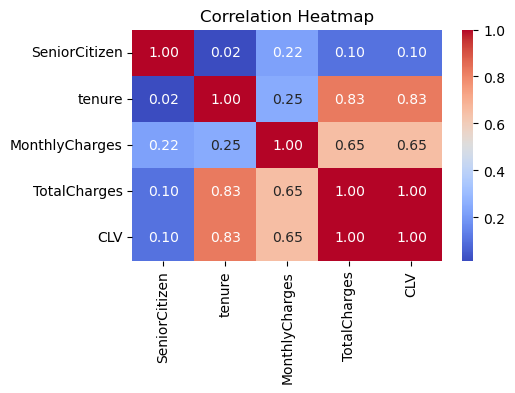

In [23]:
plt.figure(figsize=(5,3))

corr = df.select_dtypes(include=np.number).corr()
sns.heatmap(
    corr,
    annot=True,
    cmap="coolwarm",
    fmt=".2f"
)
plt.title("Correlation Heatmap")
plt.show()

#Bu qrafik numeric sütunlar arasındakı əlaqəni göstərir.

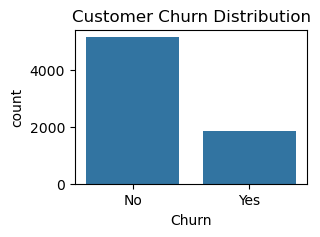

In [24]:
plt.figure(figsize=(3,2))

sns.countplot(data=df, x="Churn")

plt.title("Customer Churn Distribution")
plt.show()

#Bu qrafik neçə müştərinin qaldığını və neçə müştərinin ayrıldığını göstərir.

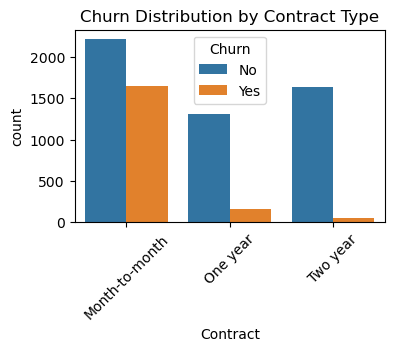

In [25]:
plt.figure(figsize=(4,2.5))

sns.countplot(
    data=df,
    x="Contract",
    hue="Churn"
)

plt.title(
    "Churn Distribution by Contract Type"
)

plt.xticks(rotation=45)
plt.show()

#Bu qrafik müqavilə növünün churn ilə əlaqəsini göstərir.

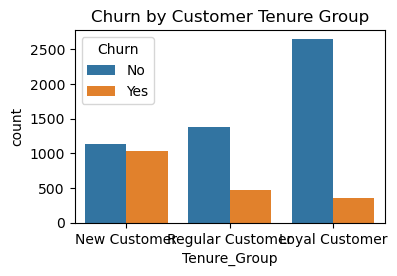

In [26]:
plt.figure(figsize=(4,2.5))
sns.countplot(
    data=df,
    x="Tenure_Group",
    hue="Churn"
)
plt.title(
    "Churn by Customer Tenure Group"
)
plt.show()


# Bu qrafik müştərinin qalma müddətinin churn-a təsirini göstərir.


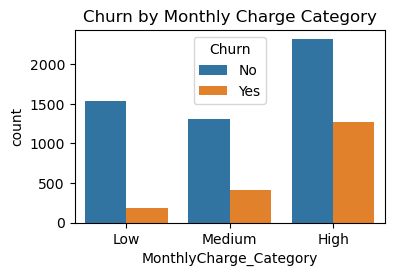

In [27]:
plt.figure(figsize=(4,2.5))

sns.countplot(
    data=df,
    x="MonthlyCharge_Category",
    hue="Churn"
)

plt.title(
    "Churn by Monthly Charge Category"
)

plt.show()


#Bu qrafik aylıq ödəniş səviyyəsinin churn ilə əlaqəsini göstərir.

CheckPoint 6

1) TotalCharges sütununu analiz edərkən çatışmayan dəyərlərin NaN deyil, boşluq (" ") formatında saxlanıldığını gördüm. Bu dəyərləri NaN-a çevirdim və cəmi 11 sətir olduğu üçün datasetin keyfiyyətini qorumaq məqsədilə həmin sətirləri sildim. 

2) IQR metodundan istifadə edərək numeric sütunlarda outlier-ləri yoxladım. Analiz nəticəsində outlier tapmadığım üçün məlumatlarda heç bir dəyişiklik etmədim. 

3) Feature engineering mərhələsində CLV, Tenure_Group, MonthlyCharge_Category və Contract_Risk adlı yeni sütunlar yaratdım. Bu sütunlar müştəriləri daha mənalı qruplara ayırmağa və sonrakı analizləri daha rahat aparmağa kömək etdi. 

4) Contract və Churn qrafikini analiz etdikdə Month-to-month müqaviləsi olan müştərilərdə churn hallarının digər müqavilə növlərinə nisbətən daha çox olduğu nəticəsinə gəldim. 

5) Tenure_Group və Churn qrafikini analiz etdikdə şirkətdə daha uzun müddət qalan (Loyal Customer) müştərilərdə churn hallarının daha az olduğunu gördüm. 
6) MonthlyCharge_Category və Churn qrafikini analiz etdikdə yüksək aylıq ödəniş edən müştərilər arasında churn hallarının daha çox müşahidə olunduğunu gördüm. 

7) Correlation heatmap-i analiz etdikdə tenure və TotalCharges arasında güclü müsbət korrelyasiya olduğunu gördüm. Bu nəticə müştərinin şirkətdə qalma müddəti artdıqca ümumi ödəniş məbləğinin də artdığını göstərir.

CheckPoint 7

Bu notebook-u bütün checkpoint-lər üzrə ardıcıl şəkildə hazırlamışam və hər mərhələni ayrıca markdown hissəsi ilə qısa izah etmişəm.

 Əvvəlcə dataseti yükləyib ilkin analiz apardım, daha sonra missing value-ləri təmizlədim, outlier analizini etdim, yeni feature-lər yaratdım və 
 vizuallaşdırmalar vasitəsilə məlumatı daha ətraflı araşdırdım. 
 
 Sonda isə əsas nəticələri ümumiləşdirdim. Hamısını week 1 checkpoint'lərdə qısa qısa bildirmişəm.


Notebook-u elə etdim ki, kod başdan sona ardıcıl şəkildə işləsin və əlavə dəyişiklik etmədən anlaşıqlı olsun. 

Kod bloklarını məntiqi ardıcıllıqla yerləşdirməyə, dəyişən adlarını aydın seçməyə və hər mərhələnin məqsədini qısa şəkildə izah etməyə diqqət etdim. 

Bu yanaşma həm notebook-un oxunaqlılığını artırır, həm də başqa bir istifadəçinin analizi asanlıqla izləyib təkrar etməsinə imkan yaradır.

Taskı yoxladıqca hər hissə checkpointlər üzrə aydın olacaq.